In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from pathlib import Path

from scipy.stats import linregress

ModuleNotFoundError: No module named 'scipy'

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from pathlib import Path

from scipy.stats import linregress

In [2]:
project_path = Path.cwd().parent

raw_path = project_path / "data" / "raw"
processed_path = project_path / "data" / "processed"

fund_master = pd.read_csv(processed_path / "01_fund_master_clean.csv")
nav_history = pd.read_csv(processed_path / "02_nav_history_clean.csv")
performance = pd.read_csv(processed_path / "03_scheme_performance_clean.csv")
benchmark = pd.read_csv(raw_path / "benchmark_indices.csv")

print("Loaded Successfully!")

FileNotFoundError: [Errno 2] No such file or directory: 'c:\\Users\\agraw\\OneDrive\\Desktop\\Bluestock_MF_Capstone\\data\\processed\\01_fund_master_clean.csv'

In [3]:
import os

project_path = Path.cwd().parent
processed_path = project_path / "data" / "processed"

print(os.listdir(processed_path))

['01_fund_master_cleaned.csv', '02_nav_history_cleaned.csv', '03_aum_by_fund_house_cleaned.csv', '04_monthly_sip_inflows_cleaned.csv', '05_category_inflows_cleaned.csv', '06_industry_folio_count_cleaned.csv', '07_scheme_performance_cleaned.csv', '08_investor_transactions_cleaned.csv', '09_portfolio_holdings_cleaned.csv', '10_benchmark_indices_cleaned.csv']


In [4]:
project_path = Path.cwd().parent

raw_path = project_path / "data" / "raw"
processed_path = project_path / "data" / "processed"

fund_master = pd.read_csv(processed_path / "01_fund_master_cleaned.csv")
nav_history = pd.read_csv(processed_path / "02_nav_history_cleaned.csv")
aum = pd.read_csv(processed_path / "03_aum_by_fund_house_cleaned.csv")
sip = pd.read_csv(processed_path / "04_monthly_sip_inflows_cleaned.csv")
category = pd.read_csv(processed_path / "05_category_inflows_cleaned.csv")
folio = pd.read_csv(processed_path / "06_industry_folio_count_cleaned.csv")
performance = pd.read_csv(processed_path / "07_scheme_performance_cleaned.csv")
transactions = pd.read_csv(processed_path / "08_investor_transactions_cleaned.csv")
portfolio = pd.read_csv(processed_path / "09_portfolio_holdings_cleaned.csv")
benchmark = pd.read_csv(processed_path / "10_benchmark_indices_cleaned.csv")

print("All datasets loaded successfully!")

All datasets loaded successfully!


In [5]:
nav_history.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [6]:
nav_history["date"] = pd.to_datetime(nav_history["date"])
benchmark["date"] = pd.to_datetime(benchmark["date"])

In [7]:
# Sort values by fund and date
nav_history = nav_history.sort_values(["amfi_code", "date"])

# Calculate daily return
nav_history["daily_return"] = (
    nav_history.groupby("amfi_code")["nav"]
    .pct_change()
)

nav_history.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


In [8]:
nav_history["daily_return"].describe()

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

In [9]:
# Calculate CAGR for each fund

cagr_data = []

for fund in nav_history["amfi_code"].unique():

    fund_data = nav_history[nav_history["amfi_code"] == fund]

    start_nav = fund_data.iloc[0]["nav"]
    end_nav = fund_data.iloc[-1]["nav"]

    years = (
        (fund_data.iloc[-1]["date"] - fund_data.iloc[0]["date"]).days
    ) / 365.25

    cagr = ((end_nav / start_nav) ** (1 / years) - 1) * 100

    cagr_data.append([fund, cagr])

cagr_df = pd.DataFrame(
    cagr_data,
    columns=["amfi_code", "cagr_pct"]
)

cagr_df.head()

,amfi_code,cagr_pct
0,100016,2.637074
1,100025,4.458210
2,100033,30.123153
3,101206,23.538361
4,101207,7.938765


In [10]:
# Risk-free rate (annual)
risk_free_rate = 0.065

# Convert annual risk-free rate to daily
daily_rf = risk_free_rate / 252

sharpe_list = []

for fund in nav_history["amfi_code"].unique():

    fund_returns = nav_history[
        nav_history["amfi_code"] == fund
    ]["daily_return"].dropna()

    avg_return = fund_returns.mean()

    volatility = fund_returns.std()

    sharpe = (
        (avg_return - daily_rf)
        / volatility
    ) * np.sqrt(252)

    sharpe_list.append([fund, sharpe])

sharpe_df = pd.DataFrame(
    sharpe_list,
    columns=["amfi_code", "sharpe_ratio"]
)

sharpe_df.head()

,amfi_code,sharpe_ratio
0,100016,-0.201517
1,100025,-0.567095
2,100033,1.093699
3,101206,1.027213
4,101207,0.162661


In [11]:
sharpe_df = sharpe_df.sort_values(
    "sharpe_ratio",
    ascending=False
)

sharpe_df.head(10)

,amfi_code,sharpe_ratio
34,148567,1.448291
30,120843,1.306744
36,148569,1.234930
19,119551,1.208267
25,120505,1.180101
38,149323,1.132122
2,100033,1.093699
9,118632,1.081659
3,101206,1.027213
24,120504,1.026524


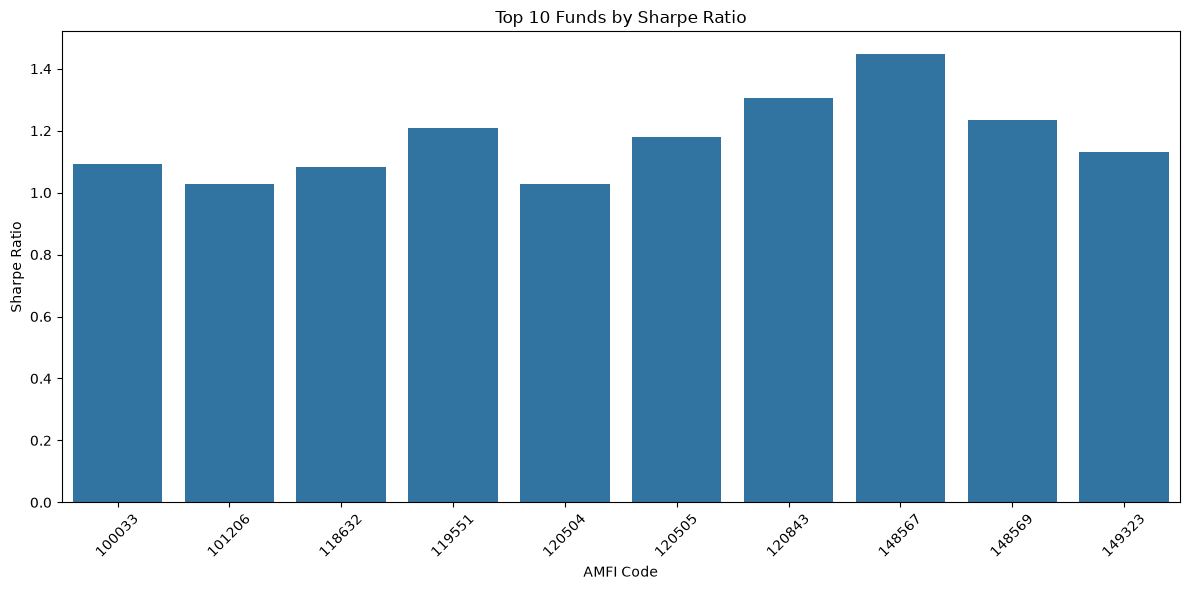

In [12]:
top10 = sharpe_df.head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top10,
    x="amfi_code",
    y="sharpe_ratio"
)

plt.title("Top 10 Funds by Sharpe Ratio")

plt.xlabel("AMFI Code")

plt.ylabel("Sharpe Ratio")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

### Observation: Sharpe Ratio

Funds with higher Sharpe Ratios generated better risk-adjusted returns, indicating superior performance after considering volatility. These funds offered more return for every unit of risk taken by investors.

In [13]:
sortino_list = []

for fund in nav_history["amfi_code"].unique():

    fund_returns = nav_history[
        nav_history["amfi_code"] == fund
    ]["daily_return"].dropna()

    avg_return = fund_returns.mean()

    # Only negative returns
    downside_returns = fund_returns[fund_returns < 0]

    downside_std = downside_returns.std()

    if downside_std == 0 or np.isnan(downside_std):
        sortino = np.nan
    else:
        sortino = (
            (avg_return - daily_rf)
            / downside_std
        ) * np.sqrt(252)

    sortino_list.append([fund, sortino])

sortino_df = pd.DataFrame(
    sortino_list,
    columns=["amfi_code", "sortino_ratio"]
)

sortino_df.head()

,amfi_code,sortino_ratio
0,100016,-0.351047
1,100025,-0.941821
2,100033,1.829134
3,101206,1.799563
4,101207,0.276644


In [14]:
sortino_df = sortino_df.sort_values(
    "sortino_ratio",
    ascending=False
)

sortino_df.head(10)

,amfi_code,sortino_ratio
34,148567,2.385644
30,120843,2.364320
36,148569,2.146914
19,119551,2.140267
25,120505,2.029353
38,149323,1.875101
9,118632,1.850133
2,100033,1.829134
24,120504,1.805294
3,101206,1.799563


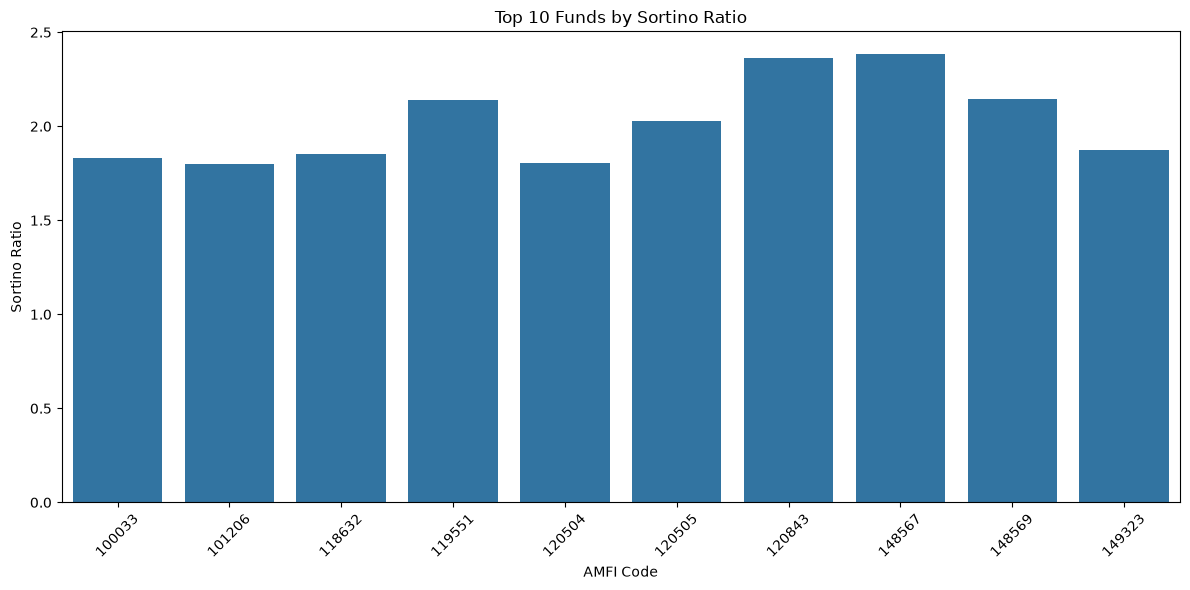

In [15]:
top10 = sortino_df.head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top10,
    x="amfi_code",
    y="sortino_ratio"
)

plt.title("Top 10 Funds by Sortino Ratio")

plt.xlabel("AMFI Code")

plt.ylabel("Sortino Ratio")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

### Observation: Sortino Ratio

The Sortino Ratio considers only downside volatility, making it a more focused measure of downside risk. Funds with higher Sortino Ratios delivered superior returns while minimizing negative return fluctuations.